C:\Users\USER-PC\anaconda3\envs\my-work-env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


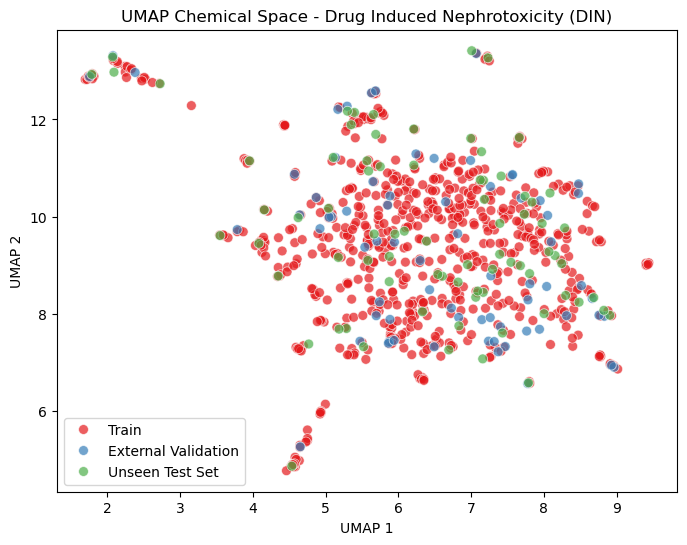

In [4]:
import pandas as pd
import numpy as np
from umap import UMAP
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# FILE DATASET
# ==============================
train_file = r"C:\Fauzan\Manuscripts QSAR-RA 2\AD Analysis\Drug Induced Nephrotoxicity\Train_Set_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
test_files = [
    r"C:\Fauzan\Manuscripts QSAR-RA 2\AD Analysis\Drug Induced Nephrotoxicity\External Validation_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx",
    r"C:\Fauzan\Manuscripts QSAR-RA 2\AD Analysis\Drug Induced Nephrotoxicity\Test_Set_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
]

# ==============================
# LOAD DATA
# ==============================
train_df = pd.read_excel(train_file)
test_dfs = [pd.read_excel(f) for f in test_files]

datasets = {'Train': train_df, 'External Validation': test_dfs[0], 'Unseen Test Set': test_dfs[1]}

# ==============================
# FUNCTION: Convert Morgan descriptor string to array
# ==============================
def morgan_to_array(desc):
    """
    Konversi string Morgan_Descriptors seperti '[0, 1, 0, ...]' menjadi array numerik
    """
    if pd.isna(desc):
        return np.array([])
    if isinstance(desc, str):
        # hapus [ dan ], newline, dan spasi ekstra
        desc_clean = desc.replace('[','').replace(']','').replace('\n','').strip()
        if desc_clean == '':
            return np.array([])
        return np.array([int(x) for x in desc_clean.split(',')])
    elif isinstance(desc, (list, np.ndarray)):
        return np.array(desc)
    else:
        return np.array([])

# ==============================
# CONVERT MORGAN DESCRIPTORS
# ==============================
for name, df in datasets.items():
    df['Morgan_FP'] = df['Morgan_Descriptors'].apply(morgan_to_array)

# ==============================
# PREPARE DATA FOR UMAP
# ==============================
all_fps = []
labels = []
for name, df in datasets.items():
    fps = [fp for fp in df['Morgan_FP'] if len(fp) > 0]
    all_fps.extend(fps)
    labels.extend([name]*len(fps))

all_fps = np.array(all_fps)

# ==============================
# UMAP DIMENSIONALITY REDUCTION
# ==============================
umap_model = UMAP(n_components=2, random_state=42)
umap_results = umap_model.fit_transform(all_fps)

# ==============================
# PLOT CHEMICAL SPACE
# ==============================
plt.figure(figsize=(8,6))
sns.scatterplot(x=umap_results[:,0], y=umap_results[:,1], hue=labels, palette='Set1', s=50, alpha=0.7)
plt.title("UMAP Chemical Space - Drug Induced Nephrotoxicity (DIN)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()